<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Image Convolutions**


## **Introduction**

The inserted image below shows the basic idea of image convolution. An image can be viewed as a grid of pixel values. A **kernel** is a small matrix that slides across the image and checks for a specific pattern, such as a vertical edge, horizontal edge, diagonal edge, corner, or spot.

At each position, the kernel is multiplied with a small region of the image, and the results are added together. This produces one value in the output. After the kernel moves across the full image, these output values form a **feature map**. The feature map highlights where the chosen pattern appears in the image.

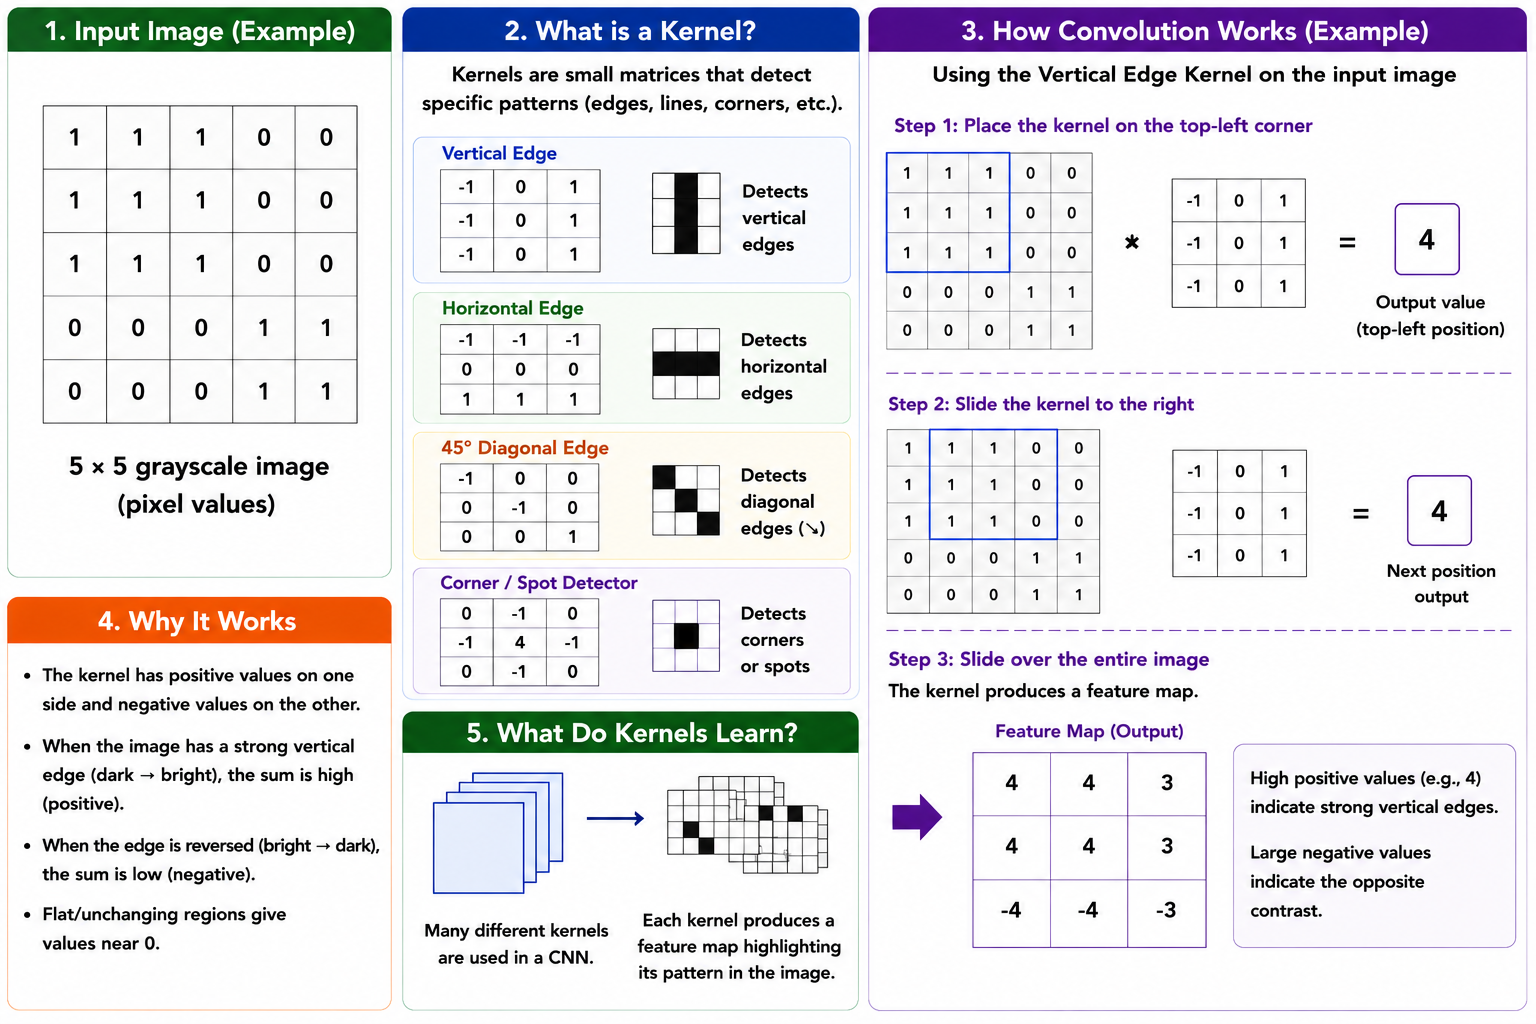


In this lab, we will explore why convolutions are useful, how kernels detect patterns in images, and how different kernels can produce different visual effects.

## **Use Case**

You have recently been contacted by a botanical garden. They want to use pictures of their flowers to create molds of flowers and use them to create clay models for children to paint.

The challenge is that there is no easy manual way to identify where the flowers are in each picture. This would take a long time if every image had to be checked by hand.

Convolution helps with this problem because kernels can highlight important image features, such as edges, shapes, and boundaries. These features can help a model locate objects like flowers in an image.

<img src="https://c.pxhere.com/photos/b5/0b/girl_garden_child_run_oleander_mediterranean_dress_summer-956570.jpg!d" width="600" alt="tulip flower">

<!-- Original Source: https://slate.com/human-interest/2020/06/a-quest-to-catalogue-every-single-house-number-in-one-suburban-zip-code.html -->


## **Table of Contents**

1. [Objectives](#toc-objectives)
2. [Setup](#toc-setup)
    1. [Installing Required Libraries](#toc-installing-required-libraries)
    2. [Importing Required Libraries](#toc-importing-required-libraries)
3. [Background](#toc-background)
    1. [What does a CNN do?](#toc-what-does-a-cnn-do)
    2. [Second step](#toc-second-step)
    3. [Size of the Output Image](#toc-size-of-the-output-image)
    4. [Why Perform Convolution?](#toc-why-perform-convolution)
4. [Importing data](#toc-importing-data)
5. [Exercise: Playing with kernels](#toc-exercise-playing-with-kernels)
6. [Types of kernels](#toc-types-of-kernels)
    1. [Edge detection Kernels](#toc-edge-detection-kernels)
7. [Exercise 1: Implementing Edge Detection](#toc-exercise-1-implementing-edge-detection)
    1. [Building the Convolutional Neural Network](#toc-building-the-convolutional-neural-network)
8. [Exercise 2: Corner and Blob detection](#toc-exercise-2-corner-and-blob-detection)
    1. [Difference of Gaussians (DoG)](#toc-difference-of-gaussians-dog)
9. [Other kernels](#toc-other-kernels)
    1. [Classical Feature Detectors vs. CNNs](#toc-classical-feature-detectors-vs-cnns)


<a id="Objectives"></a>

## **Objectives** <a id="toc-objectives"></a>

After completing this lab you will be able to:

*   Explain how a convolution works on images
*   Understand the purposes of different kernels that exist
*   Apply kernels to images and obtain a useful result


***


<a id="Setup"></a>

## **Setup** <a id="toc-setup"></a>


For this lab, we will be using the following libraries:

*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`Pillow`](https://pillow.readthedocs.io/en/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for image processing functions.
*   [`OpenCV`](https://docs.opencv.org/4.x/index.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for other image processing functions.
*   [`tensorflow`](https://www.tensorflow.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and neural network related functions.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### **Installing Required Libraries** <a id="toc-installing-required-libraries"></a>

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run these notebook commands in a different Jupyter environment (like Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `!mamba` in the code cell below.


In [1]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy numpy==1.22.3 matplotlib==3.5.1 tensorflow==2.9.0 opencv-python==4.5.5.62

# Note: If your environment doesn't support "!mamba install", use "!pip install --user"

# RESTART YOUR KERNEL AFTERWARD AS WELL

!pip install --upgrade tensorflow

### **Importing Required Libraries** <a id="toc-importing-required-libraries"></a>

*We recommend you import all required libraries in one place (here):*


In [2]:
# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass


import warnings

warnings.warn = warn
warnings.filterwarnings("ignore")

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = (
    "2"  # tensorflow INFO and WARNING messages are not printed
)

In [3]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import PIL
from PIL import Image, ImageOps
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

import cv2

<a id="Background"></a>

## **Background** <a id="toc-background"></a>

Humans can easily recognize objects in an image. For example, when looking at a flower, we can quickly identify the petals by observing their shapes, edges, colors, and positions. Even in a complex image, our brains can separate important objects from the background with little effort.

Computers, however, do not naturally understand images. To a computer, an image is simply a grid of numerical pixel values. In order to recognize patterns such as edges, shapes, or textures, the computer needs mathematical methods to process the image data.

Convolutional Neural Networks (CNNs) solve this problem using an operation called **convolution**. Convolutions apply small matrices called **kernels** or **filters** across an image to detect important features such as edges, corners, and patterns.

Using different filters, CNNs can learn increasingly complex features from images and eventually identify objects such as flowers, animals, or handwritten digits.

In the following sections, we will explore how convolutions work and how CNNs use them for image classification.


### **What does a CNN do?** <a id="toc-what-does-a-cnn-do"></a>

A Convolutional Neural Network (CNN) is a type of neural network designed for processing image data. CNNs analyze images by detecting important features such as edges, shapes, textures, and patterns.

A CNN works by moving a small matrix called a **kernel** or **filter** across the input image. At each position, the kernel performs element-wise multiplication with a small region of the image and then adds the results together to produce a single output value.

In this example:

- the input image has size $5 \times 5$
- the kernel has size $3 \times 3$

<div style="text-align:center">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/convolution.png" width="600" alt="convolution example">
</div>

For example:

- the top-left value of the kernel multiplies the top-left pixel of the image
- the next kernel value multiplies the next image pixel
- this continues for all values in the $3 \times 3$ region

After all element-wise multiplications are completed, the results are added together to produce one value in the output feature map.

#### **What are we computing?**

The values in the image represent pixel brightness intensities.

For grayscale images, pixel values typically range from $0$ to $255$. $0$ represents black. $255$ represents white

Since this example contains only one matrix, the image has a single channel, meaning it is a grayscale image.

Color images usually contain three channels: Red (R), Green (G) and Blue (B). In that case, convolution is performed separately on each channel, and the results are combined together. Multi-channel convolution will be discussed in a later section.

The final summed value becomes one pixel in the output image, also called a **feature map**.


### **Second step** <a id="toc-second-step"></a>

We now *shift* the kernel one step right on the input image, and recalculate the element wise multiplication of our kernel with the new 3x3 window on the input image. This produces the next pixel value of our output image. The number of pixels we shift by is referred to as the `stride`, and in this example it is `1`.

<div style="text-align:center">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/convolution-1.png" width="600" alt="convolution example 2">
</div>

We can continue to shift our window over the input image until we have covered the entire image. Now we will have an output image of 3x3 which we can pass to the next layer. This whole process is known as convolution, which is where Convolutional Neural Networks get their name.


### **Size of the Output Image** <a id="toc-size-of-the-output-image"></a>

Notice that the output image is $3 \times 3$, while the input image is $5 \times 5$. This happens because the kernel is $3 \times 3$, and the convolution operation only works where the entire kernel can fully overlap the input image.

For each output pixel, the kernel uses a $3 \times 3$ region from the input image. Border pixels do not have enough surrounding neighbors for the kernel to fit completely, so they are excluded from the calculation.

The output size can be calculated using:

$$
M_{out} = M_{in} - (K - 1)
$$

where:

- $M_{in}$ is the width (or height) of the input image
- $K$ is the kernel size
- $M_{out}$ is the width (or height) of the output image

For this example:

$$
\begin{aligned}
M_{in} &= 5 \\
K &= 3 \\
M_{out} &= 5 - (3 - 1) = 3
\end{aligned}
$$

So, a $5 \times 5$ image convolved with a $3 \times 3$ kernel produces a $3 \times 3$ output image.

The final output is shown below.

<div style="text-align:center">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/convolution.gif" width="700" alt="convolution example 3">
</div>

### **Why Perform Convolution?** <a id="toc-why-perform-convolution"></a>

Convolution allows a CNN to detect useful patterns and features in an image, such as: edges, horizontal lines, vertical lines, textures and shapes. Different kernels detect different types of features.

In the example above, the kernel is called a **Prewitt kernel**, which is commonly used for edge detection. This particular kernel is designed to highlight **vertical edges** in an image. By stacking many convolution layers together, CNNs can gradually learn more complex features, from simple edges in early layers to complete objects in deeper layers.


## **Importing data** <a id="toc-importing-data"></a>

Lets take a look at the flowers dataset from tensorflow, retrieved from here: [https://www.tensorflow.org/datasets/catalog/tf_flowers](https://www.tensorflow.org/datasets/catalog/tf_flowers?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01)


In [4]:
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/flower_photos.tgz"
data_dir = keras.utils.get_file(
    origin=dataset_url, fname="flower_photos", untar=True
)

data_dir = pathlib.Path(data_dir)

for folder in data_dir.glob("[!LICENSE]*"):
    print(
        "The",
        folder.name,
        "folder has",
        len(list(folder.glob("*.jpg"))),
        "pictures",
    )
image_count = len(list(data_dir.glob("*/*.jpg")))
print(image_count, "total images")

The flower_photos folder has 0 pictures
0 total images


Let's extract some images we can use for this lab. We will set them all to be square images of 300x300, and display them as well.


In [ ]:
# The next cell loads and displays sample images robustly across local environments.

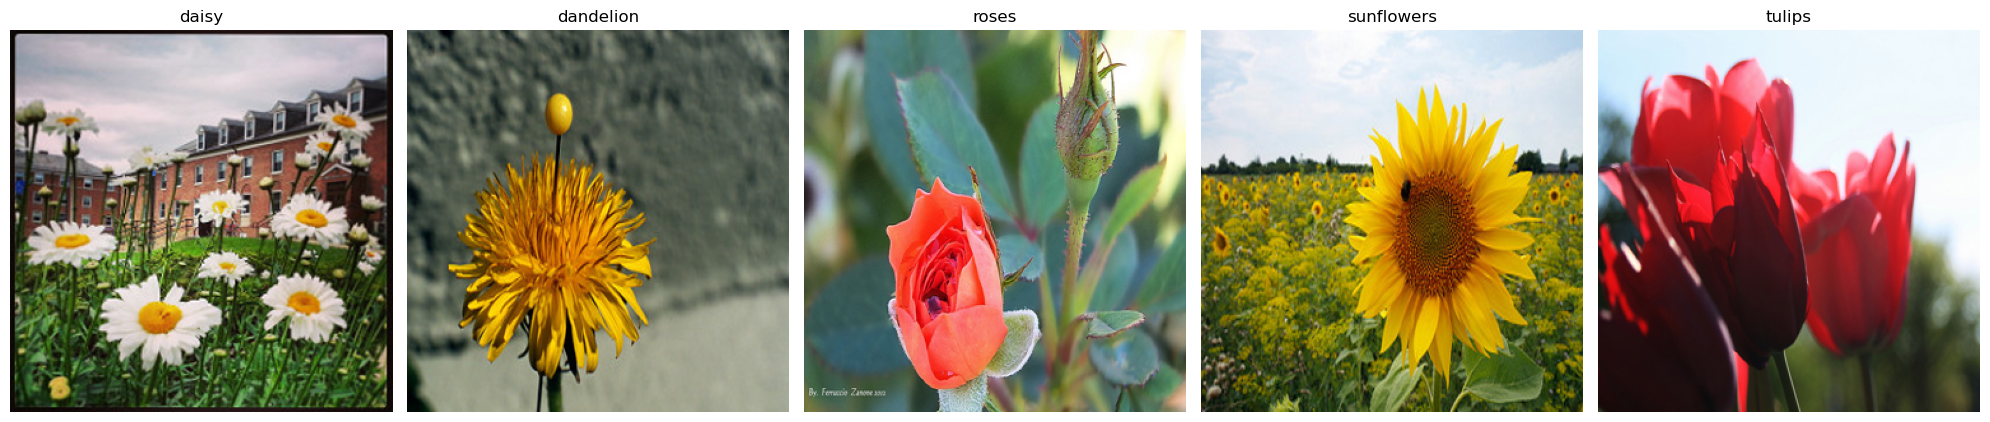

In [6]:
import pathlib
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

pics = []
pics_arr = []
p_class = []

img_width = 300
img_height = 300
img_exts = {".jpg", ".jpeg", ".png"}

# --- Fix 1: point data_dir to the real root that contains class folders ---
data_dir = pathlib.Path(data_dir)

# Some archives unzip into .../flower_photos/flower_photos/<class_folders>
if (data_dir / "flower_photos").is_dir():
    data_dir = data_dir / "flower_photos"

# --- Fix 2: only iterate over actual class directories ---
class_folders = sorted([p for p in data_dir.iterdir() if p.is_dir()])

plt.figure(figsize=(20, 5))

# show up to 5 classes so subplot(1,5,...) doesn't break
for idx, folder in enumerate(class_folders[:5]):
    # --- Fix 3: only collect image files ---
    cat = [
        p
        for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in img_exts
    ]

    if not cat:
        print(f"Skipping {folder.name}: no image files found")
        continue

    img_path = random.choice(cat)

    try:
        pic = Image.open(img_path).resize((img_width, img_height))
    except UnidentifiedImageError:
        print(f"Skipping unreadable image: {img_path}")
        continue

    pic_arr = np.array(pic)
    clss = folder.name

    plt.subplot(1, 5, idx + 1)
    plt.imshow(pic)
    plt.title(clss)
    plt.axis("off")

    pics.append(pic)
    pics_arr.append(pic_arr)
    p_class.append(clss)

plt.tight_layout()
plt.show()

We can see that after importing our images, they're all exactly square with `300 x 300` pixels.


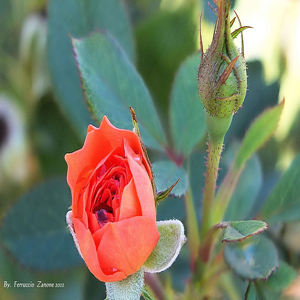

In [7]:
# Lets get an image to use for the rest of the exercises
img = pics[2]
img

<a id="Exercises"></a>

## **Exercise: Playing with kernels** <a id="toc-exercise-playing-with-kernels"></a>

Now that we have our images, lets play around with the CNN tools we learned.

In this section, we will see what kernels can do for us. See here for more information: https://en.wikipedia.org/wiki/Feature_(computer_vision)

## **Types of kernels** <a id="toc-types-of-kernels"></a>

There exist many kernels used in Computer Vision, and we'll explore some of them and see what they do with our images.

### **Edge detection Kernels** <a id="toc-edge-detection-kernels"></a>

[**Prewitt Operator**](https://en.wikipedia.org/wiki/Prewitt_operator?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01)

This computes an approximation of the gradient between pixels in an image. It's commonly used for edge detection.

This operator convolves two kernels with an input image, and then approximates the gradient.

\begin{align*}
G_x = \begin{bmatrix}
1 & 0 & -1\\
1 & 0 & -1\\
1 & 0 & -1\\
\end{bmatrix} * \text{Img} \quad
G_y = \begin{bmatrix}
1 & 1 & 1\\
0 & 0 & 0\\
-1 & -1 & -1\\
\end{bmatrix} * \text{Img}
\end{align*}

[**Sobel Operator**](https://en.wikipedia.org/wiki/Sobel_operator?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01)\
The Sobel operator performs edge detection just like the Prewitt operator, except with slightly different kernels.

\begin{align*}
G_x = \begin{bmatrix}
1 & 0 & -1\\
2 & 0 & -2\\
1 & 0 & -1\\
\end{bmatrix} * \text{Img} \quad
G_y = \begin{bmatrix}
1 & 2 & 1\\
0 & 0 & 0\\
-1 & -2 & -1\\
\end{bmatrix} * \text{Img}
\end{align*}

Where:
- $G_x$ represents the horizontal gradient approximations;
- $G_y$ represents the vertical gradient approximations;
- Img is the original input image.


To get the edges, we combine the two gradient approximations from above to produce a gradient magnitude $G$ using:

\begin{align*}
G = \sqrt{G_x^2 + G_y^2}
\end{align*}

Which will be a pixel value that is large when there is an edge (large change in pixel brightness) and small when there is a smooth transition between pixels.

Lets try to implement the Sobel operator using Keras and Numpy.


<a id="E1"></a>

## **Exercise 1: Implementing Edge Detection** <a id="toc-exercise-1-implementing-edge-detection"></a>


In [8]:
# Lets define our custom kernels for the horizontal and vertical gradients
def v_grad(shape, dtype=None):
    # Here we use a single numpy array to define our x gradient kernel
    grad = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]]).reshape((3, 3, 1, 1))
    # this line is quite important, we are saying we want one 3x3 kernel each for one channel of pixels (grayscale)

    # We check to make sure the shape of our kernel is the correct shape
    # according to the initialization of the Convolutional layer below
    assert grad.shape == shape
    return keras.backend.variable(grad, dtype="float32")


def h_grad(shape, dtype=None):
    grad = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]]).reshape((3, 3, 1, 1))

    assert grad.shape == shape
    return keras.backend.variable(grad, dtype="float32")

### **Building the Convolutional Neural Network** <a id="toc-building-the-convolutional-neural-network"></a>

Here we will build two very simple one layer convolutional neural networks, which will just apply our kernels over an input image. The definition of the function is below.

**keras.layers.Conv2d**

```python
keras.layers.convolutional.Conv2D(filters, kernel_size, strides=(1, 1), padding='valid', data_format=None, dilation_rate=(1, 1), activation=None, use_bias=True, kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=None, bias_regularizer=None, activity_regularizer=None, kernel_constraint=None, bias_constraint=None, **kwargs)
```


In [9]:
# We define the input layer of our Neural Network
# to take in an image of 300x300 with 1 channel
# Both our models can share this, as it will not change between the two

input_layer = layers.Input(shape=(img_width, img_height, 1))

h_conv = layers.Conv2D(
    filters=1,  # the number of kernels we are using, kernel and filter are interchangeable terms
    kernel_size=3,
    kernel_initializer=h_grad,
    strides=1,
    padding="valid",
)  # 'valid' means no padding

v_conv = layers.Conv2D(
    filters=1,
    kernel_size=3,
    kernel_initializer=v_grad,
    strides=1,
    padding="valid",
)


h_model = keras.Sequential([input_layer, h_conv])
v_model = keras.Sequential([input_layer, v_conv])

So we've built a very simple neural network with predefined kernels in our convolutional layer. In practice, there are many ways to initialize your kernels.

Below we have a summary of our model! We can see that there is just a layer that produces a matrix slightly smaller than our input image size of `300x300`, but we also get two matrices which each represent the x and y gradients.


In [10]:
h_model.summary()
v_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 298, 298, 1)    │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 298, 298, 1)    │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

We must convert our RGB image to grayscale, since our CNN models were only designed to apply 1 kernel to 1 channel of input.


In [11]:
gray = ImageOps.grayscale(img)

# We need to add 1 dimension to our input image which represents the batch size
# In this case, we just want to process 1 image.
input_img = np.array(gray).reshape((1, img_width, img_height, 1))

# Pass our input image into each model, and return
# the output with a shape of (298,298,1) in variables named `Gy` and `Gx`.
# WRITE YOUR CODE HERE
Gx = h_model.predict(input_img, verbose=0)[0]
Gy = v_model.predict(input_img, verbose=0)[0]

In [12]:
# Now that we have the two gradients,
# try computing our gradient magnitude G using numpy
# WRITE YOUR CODE HERE
G = np.sqrt(np.add(np.multiply(Gx, Gx), np.multiply(Gy, Gy)))

Lets look at our image at each step of the process!


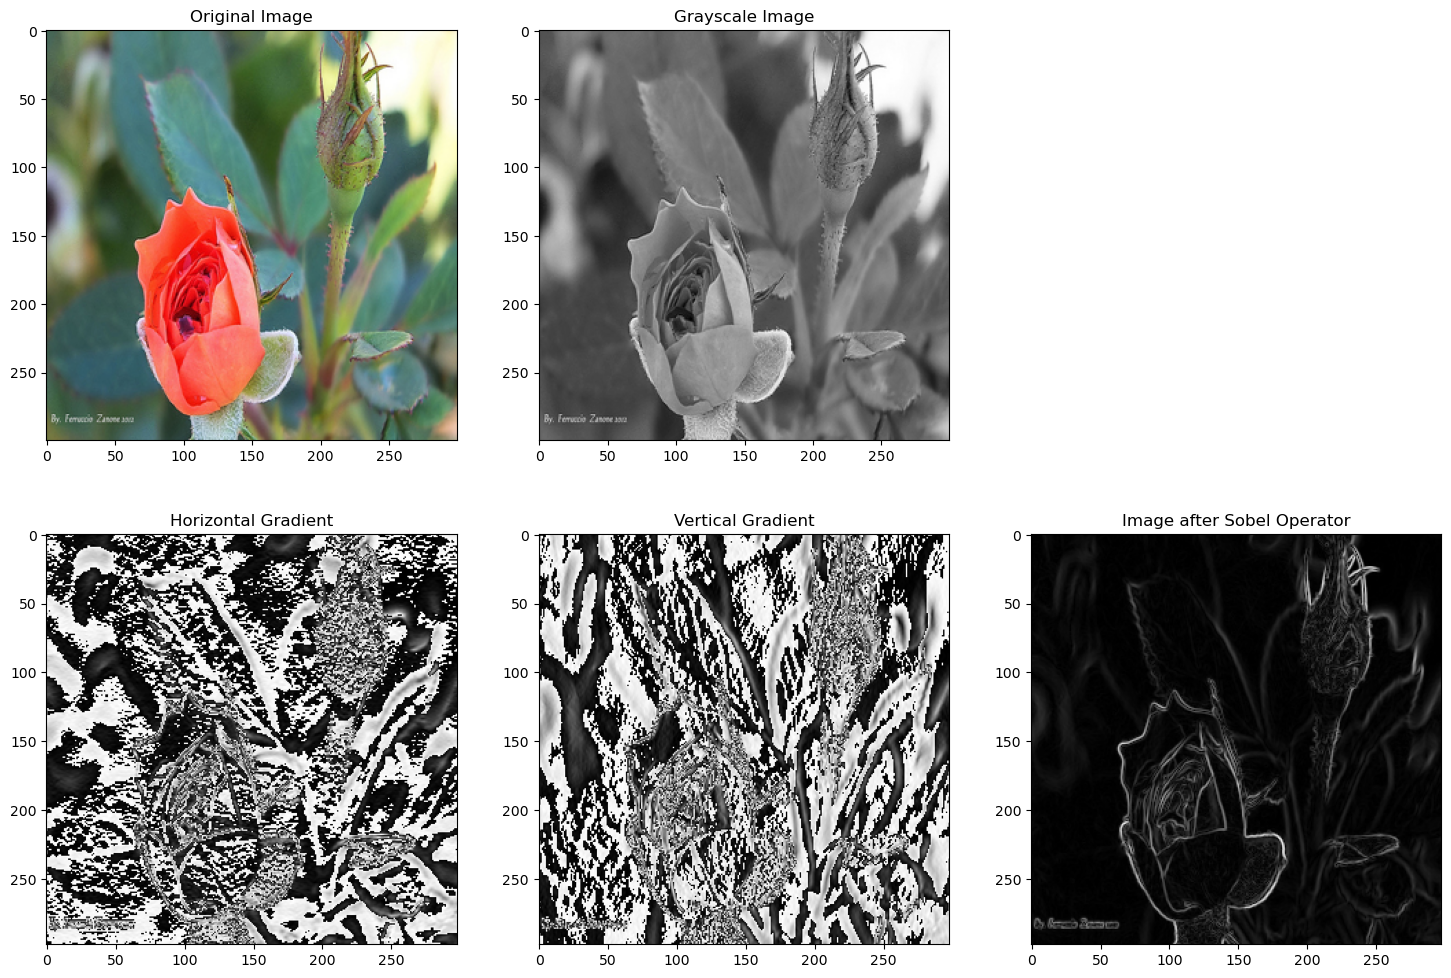

In [13]:
plt.figure(figsize=(18, 12))
plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.subplot(2, 3, 2)
plt.imshow(gray, cmap=plt.get_cmap("gray"))
plt.title("Grayscale Image")
plt.subplot(2, 3, 4)
plt.imshow(Gx.astype("uint8"), cmap=plt.get_cmap("gray"))
plt.title("Horizontal Gradient")
plt.subplot(2, 3, 5)
plt.imshow(Gy.astype("uint8"), cmap=plt.get_cmap("gray"))
plt.title("Vertical Gradient")
plt.subplot(2, 3, 6)
plt.imshow(G, cmap=plt.get_cmap("gray"))
plt.title("Image after Sobel Operator")
plt.show()

While you can manually hardcode traditional edge-detection filters like Sobel or Prewitt operators into a neural network layer, standard deep learning workflows rarely require this.

The core philosophy of a Convolutional Neural Network (CNN) is to move away from manually designed filters. Instead of human engineering, the network uses automatic weight optimization:

- Initial State: Convolutional layers are initialized with random weights using standard algorithms like `glorot_uniform` or `he_normal`.

- Training Process: As data flows through the pipeline and backpropagation runs, the early layers of a CNN naturally discover and reinvent Sobel-like and Prewitt-like edge detectors entirely on their own.

When building future CNNs, you should delegate kernel optimization to Keras. The model will automatically learn the precise edge and shape detectors it needs directly from your training images.


<a id="E2"></a>

## **Exercise 2: Corner and Blob detection** <a id="toc-exercise-2-corner-and-blob-detection"></a>

In computer vision, we can perform corner detection on images which could then be used to extract certain useful features or infer the contents of the image. You can learn more about it [here](https://en.wikipedia.org/wiki/Corner_detection?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01).

Blob detection is when you want to obtain regions within an image that differ in properties, such as brightness or color. In those regions, properties are relatively constant. You can learn more about this [here](https://en.wikipedia.org/wiki/Blob_detection?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01).

### [Difference of Gaussians (DoG)](https://en.wikipedia.org/wiki/Difference_of_Gaussians?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01) <a id="toc-difference-of-gaussians-dog"></a>

This is a method for both corner *and* blob detection. The way it works is by convolving two Gaussian kernels with different variances (sigma) over an image which will produce two blurred versions of the input image. We then subtract the two blurred images and get the resulting DoG processed image which should make it easy to identify corners and blobs.

The convolution can be illustrated with the following equation:

\begin{align*}
\Gamma_{\sigma_1, \sigma_2}(x,y)=
I \cdot \frac {1}{2\pi \sigma_1^{2}} e^{ - \frac {x^{2}+y^{2}}{2\sigma_1^{2}} } -
I \cdot \frac {1}{2\pi \sigma_2^{2}} e^{ - \frac {x^{2}+y^{2}}{2\sigma_2^{2}} }
\end{align*}

Where

*   the first term represents the image convolved with the first Gaussian with mean $0$, variance $\sigma_1^2$ and
*   the second term represents the image convolved with the second Gaussian with mean $0$, variance $\sigma_2^2$.

Note that $\sigma_2^2 > \sigma_1^2$.


There are built in methods such as scipy's `scipy.ndimage.filters.gaussian_filter` or OpenCV's `cv2.GaussianBlur` which can perform the convolution with a Gaussian kernel for you.

We can implement the `cv2.GaussianBlur` function here!


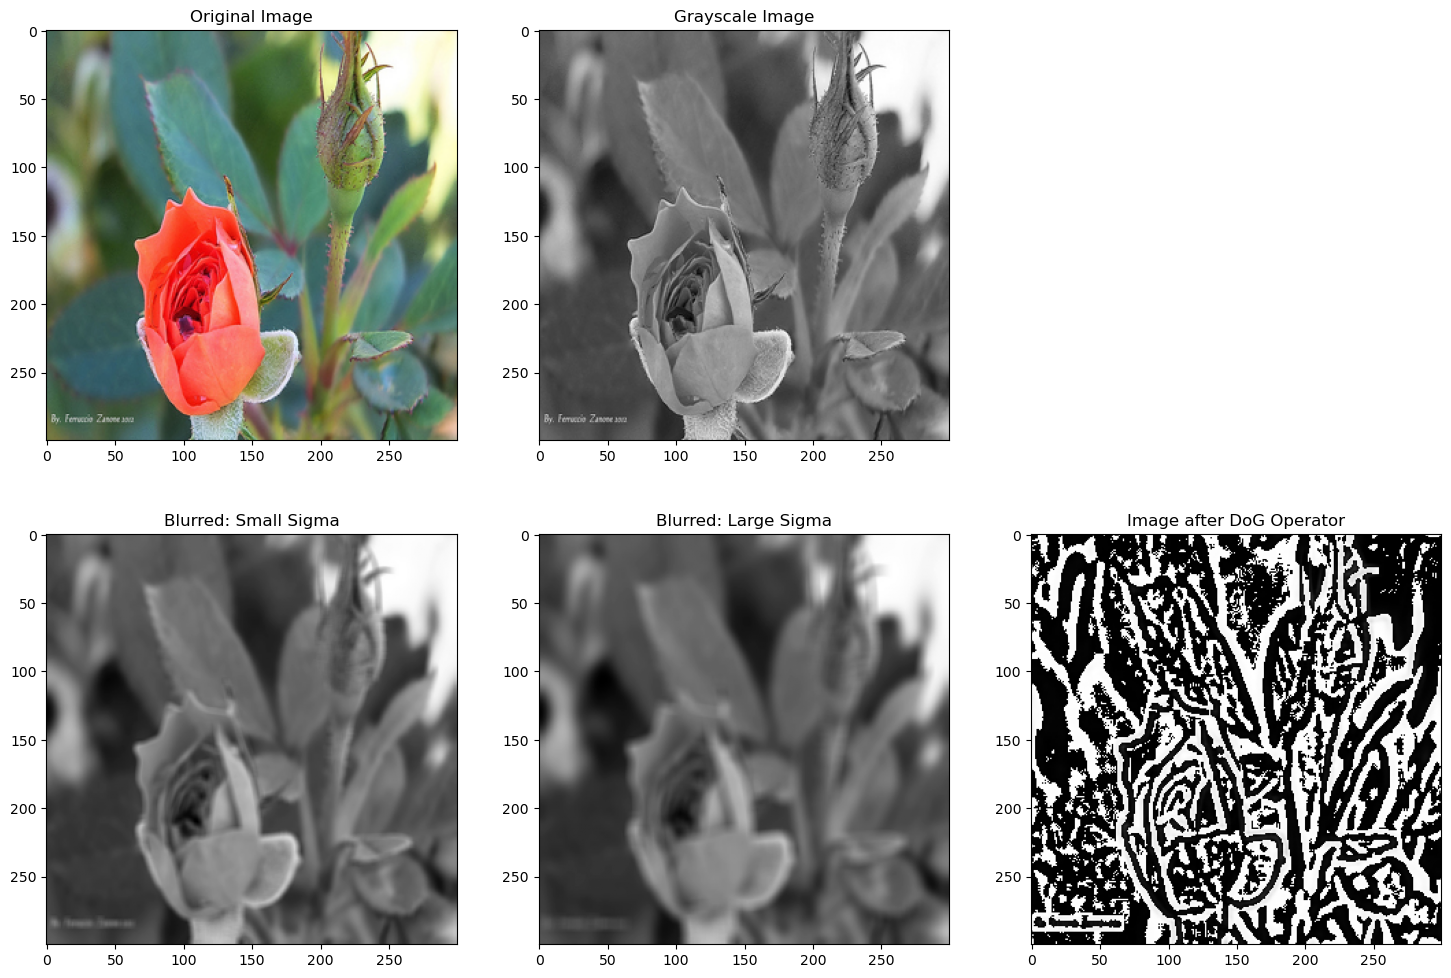

In [14]:
sigma_sm = 5
sigma_lg = 9
blurred_sm = cv2.GaussianBlur(np.array(gray), (sigma_sm, sigma_sm), sigma_sm)
blurred_lg = cv2.GaussianBlur(np.array(gray), (sigma_lg, sigma_lg), sigma_lg)

DoG = blurred_sm - blurred_lg

plt.figure(figsize=(18, 12))
plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.subplot(2, 3, 2)
plt.imshow(gray, cmap=plt.get_cmap("gray"))
plt.title("Grayscale Image")
plt.subplot(2, 3, 4)
plt.imshow(blurred_sm.astype("uint8"), cmap=plt.get_cmap("gray"))
plt.title("Blurred: Small Sigma")
plt.subplot(2, 3, 5)
plt.imshow(blurred_lg.astype("uint8"), cmap=plt.get_cmap("gray"))
plt.title("Blurred: Large Sigma")
plt.subplot(2, 3, 6)
plt.imshow(DoG.astype("uint8"), cmap=plt.get_cmap("gray"))
plt.title("Image after DoG Operator")
plt.show()

We've now seen how Difference of Gaussians can help us identify the outlines (corners and edges) of objects as well as blobs (areas with very similar properties) very clearly. These methods were all applied by convolving specific kernels over images! I hope this lab has given you a good understanding of how convolutions work, the types of kernels used for specific applications, and why they're useful.


With Difference of Gaussians, we can greatly enhance features within an image by applying two Gaussian kernels to the same image, and take their difference. This technique greatly helps in reducing noise in an image, and results in clearly defined corners of shapes, as well as easily identifiable blobs (regions with very similar properties).

Feel free to play around with the kernel sizes and values for `sigma_sm` and `sigma_lg` to see how those values can change our output image.


And thats it! Hopefully you gained a better understanding of image convolutions through this lab, some important kernels (filters) used in computer vision and why they are useful. You now know how we can implement them using Keras as well.

## **Other kernels** <a id="toc-other-kernels"></a>

This table is from [wikipedia](https://en.wikipedia.org/wiki/Feature_(computer_vision)#Detection), which shows all the different types of methods you can use to process images and detect different features within.

|              Feature detector             | Edge | Corner | Blob | Ridge |
|:-----------------------------------------:|:----:|:------:|:----:|:-----:|
| Canny                                     |  Yes |   No   |  No  |   No  |
| Sobel                                     |  Yes |   No   |  No  |   No  |
| Harris & Stephens / Plessey               |  Yes |   Yes  |  No  |   No  |
| SUSAN                                     |  Yes |   Yes  |  No  |   No  |
| Shi & Tomasi                              |  No  |   Yes  |  No  |   No  |
| Level curve curvature                     |  No  |   Yes  |  No  |   No  |
| FAST                                      |  No  |   Yes  |  Yes |   No  |
| Laplacian of Gaussian                     |  No  |   Yes  |  Yes |   No  |
| Difference of Gaussians                   |  No  |   Yes  |  Yes |   No  |
| Determinant of Hessian                    |  No  |   Yes  |  Yes |   No  |
| Hessian strength feature measures         |  No  |   Yes  |  Yes |   No  |
| MSER                                      |  No  |   No   |  Yes |   No  |
| Principal curvature ridges                |  No  |   No   |  No  |  Yes  |
| Grey-level blobs                          |  No  |   No   |  Yes |   No  |



### **Classical Feature Detectors vs. CNNs** <a id="toc-classical-feature-detectors-vs-cnns"></a>

CNN filters are different from the neurons (nodes) used in Dense layers. \
**In a Dense layer:**
```python
Dense(32)
```
The number `32` means 32 neurons. Each neuron performs a similar mathematical operation:

$$
y = Wx + b
$$

and produces a single output value. *The weights associated with a single node are one-dimensional (a vector).*
- Input: The input is "flattened" into a 1D vector.
- Weights: Each node has one weight for every single input element. If you have 100 inputs, the node has a 1D weight vector of size 100.
- Operation: It performs a dot product between two 1D vectors.

**In a CNN layer:**

```python
Conv2D(filters=32, kernel_size=(3,3))
```

`filters=32` means 32 different learnable filters (kernels). Each filter is a small matrix that scans across the image and acts as a feature detector. Although all filters are in the same layer, they learn different visual patterns because each filter has independent weights.
*The kernel weights, the numerical values inside the filter matrix, are are multi-dimensional (usually a 2D matrix or 3D tensor).* 
- Input: The input preserves its spatial structure (e.g., a 2D image).
- Weights: Instead of a flat list, the weights are arranged in a grid (e.g., $3 \times 3$ or $5 \times 5$). This allows the kernel to capture spatial patterns (like edges or shapes) because it looks at pixels that are physically next to each other.
- Operation: It performs a 2D convolution (sliding the matrix across the image).

**CNNs Automate Feature Detection**
At the onset of training, CNN filters are initialized with random weights. Through the process of backpropagation, the network iteratively optimizes these weights to minimize error, effectively "learning" to detect meaningful patterns. While traditional computer vision relied on manually engineered filters—such as the Sobel operator for edge detection—CNNs automate this process.

$$
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$$

A Convolutional Neural Network (CNN) begins with random weights, the network evolves during training; using backpropagation, it iteratively adjusts its filters to capture the most relevant information from the input data.

This shift from manual design to automated learning allows CNNs to build a sophisticated hierarchy of features. *The network starts by identifying simple edges and colors in the early layers, then gradually assembles these into complex shapes, and finally into recognizable objects in the deeper layers.* This ability to automatically learn and compose features is what enables deep learning to outperform traditional computer vision in complex tasks.

## **Authors**


[Richard Ye](https://linkedin.com/in/richard-ye?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01)


Richard Ye is a undergrad at the University of Toronto studying Statistics and Finance.

Su Wu

### **Other Contributors**

[Cindy Huang](https://www.linkedin.com/in/cindy-shih-ting-huang/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01)


## **Change Log**


| Date (YYYY-MM-DD) | Version | Changed By  | Change Description |
| ----------------- | ------- | ----------- | ------------------ |
| 2022-05-18        | 0.1     | Richard Ye  | Created Lab        |
| 2022-05-20        | 0.2     | Cindy Huang | Reviewed Lab       |
| 2022-07-19        | 0.3     | Steve Hord  | QA pass            |
|2026-05-19 | Student modification |Su Wu | Added explanatory documentation, code comments, and minor code edits for coursework, learning, and portfolio development|

Copyright © 2022 IBM Corporation. All rights reserved.
